# Stroke Prediction

`Author:` Isha Sarwar\
`Date:` 02 August 2025\
`Source of Dataset:` [🧠Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data)

## 🧾Meta-Data 

` 1. Introduction`

Stroke is a serious medical condition that occurs when the blood supply to the brain is disrupted, either due to a blockage (ischemic stroke) or bleeding (hemorrhagic stroke). It is one of the leading causes of death and disability worldwide. According to the World Health Organization, stroke ranks as the **second leading cause** of death globally and the third leading cause of disability. [According to the World Stroke Organization (WSO)](https://www.world-stroke.org/world-stroke-day-campaign/about-stroke), more than 12 million people suffer a first stroke each year, and approximately 6.5 million deaths are attributed to stroke-related causes. (Numbers may vary slightly depending on data source and reporting year). Early identification of individuals at high risk can significantly reduce both stroke-related mortality and long-term disability through timely intervention, preventive strategies, and targeted clinical decision support. 

`2. Purpose of the Dataset`

This dataset is designed to support predictive modeling, particularly using machine learning techniques, for identifying individuals at risk of stroke based on various health and demographic indicators. The features are structured for use in classification algorithms such as logistic regression, random forests, and neural networks, which can learn complex, non-linear relationships between health factors and stroke risk.

`3. Attribute Information:`

| Feature             | Description                                                                 | Data Type | Values / Units                                            |
|---------------------|-----------------------------------------------------------------------------|-----------|------------------------------------------------------------|
| `id`                | Unique identifier                                                           | int64     | Unique number                                              |
| `gender`            | Gender of the patient                                                       | object    | Male, Female, Other                                        |
| `age`               | Age of the patient                                                          | float64   | In years                                                   |
| `hypertension`      | Whether the patient has high blood pressure                                 | int64     | 0 = No, 1 = Yes                                            |
| `heart_disease`     | Whether the patient has heart disease                                       | int64     | 0 = No, 1 = Yes                                            |
| `ever_married`      | Marital status                                                              | object    | Yes, No                                                    |
| `work_type`         | Type of employment                                                          | object    | Children, Govt_job, Never_worked, Private, Self-employed  |
| `Residence_type`    | Type of residence                                                           | object    | Urban, Rural                                               |
| `avg_glucose_level` | Average blood glucose level                                                 | float64   | mg/dL (e.g., 85.2, 114.0)                                  |
| `bmi`               | Body mass index                                                             | float64   | kg/m² (201 missing values)                                 |
| `smoking_status`    | Smoking behavior                                                            | object    | formerly smoked, never smoked, smokes, Unknown             |
| `stroke`            | Whether a stroke occurred (Target variable)                                 | int64     | 0 = No Stroke, 1 = Stroke                                  |



**Note**: "Unknown" in smoking_status means that the information is unavailable for this patient.







## 📚 1. Importing Libraries

In [2]:
# For Data handling and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# For Statistics 
import scipy.stats as stats
from scipy.stats import kruskal, chi2_contingency

# To Preprocess the Data
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder,MinMaxScaler, QuantileTransformer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.experimental import  enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge

# For Data Balancing
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# For Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score,RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score,precision_score,recall_score, classification_report,
                    confusion_matrix, f1_score, roc_auc_score, precision_recall_curve)


#ignore warnings
import warnings
warnings.filterwarnings('ignore') #ide warning for clean output

#wider display for dataframe
pd.set_option('display.max_columns', None)

# For Tabulate the results
from tabulate import tabulate



In [3]:
# Creating function to highlight text in the console
def highlight(text, width=45):
    line='='*width
    print(line)
    print(text)
    print(line)

## 🔍 2. Data Overview 

#### 🗂️ Basic Metadata

This section provides an overview of the dataset’s structure, including the number of rows, columns, feature types, and sample entries.

In [4]:
# Load the Dataset
df= pd.read_csv('../data/raw/healthcare-dataset-stroke-data.csv')

#Display firt few rows
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# Drop the id column
df.drop('id', axis=1, inplace=True)

- The `id` column is removed as it serves only the as unique identifier and does not contribute to the predictive modeling or analysis.
- Keeping it may even introduce noise in some algorithms.

In [6]:
#check the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


- Total Samples (Rows): 5,110
- Total Features (Columns): 12
- The dataset contains both numerical and categorical data related to patients and stroke occurrence.

#### 🧮 Summary Statistics

To gain an initial understanding of the numerical variables in the dataset, we examine their summary statistics or descriptive analysis.

In [7]:
# Display Summary Statistics of Numerical Features
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


While looking at the overall dataset summary, I noticed something unusual in the age column:

- The minimum age was 0.08, which is not realistic for stroke data.

- The maximum age was 88, which seems valid.

- This suggested that there might be decimal-shift errors (e.g., 0.08 actually representing 8 years).

#### Diving Deeper into Age Column

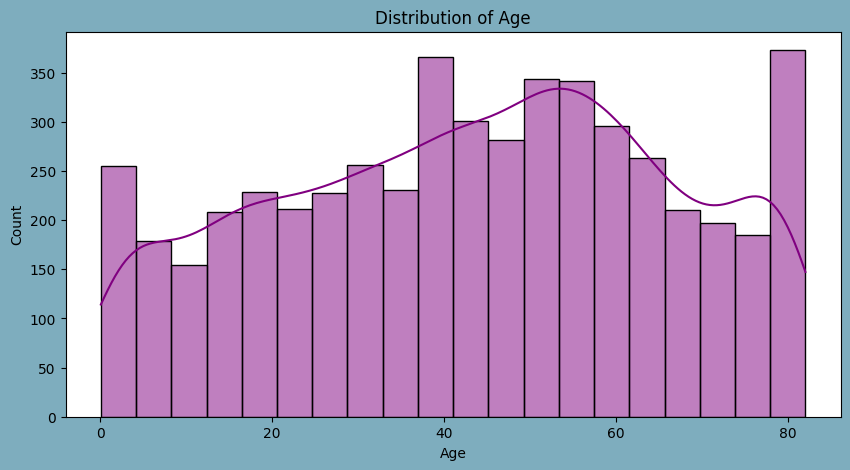

In [8]:
# check the distribution of age column

# Plot the histogram
plt.figure(figsize=(10, 5), facecolor="#7EADBE")
sns.histplot(df['age'], bins=20, kde=True, color='Purple')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

The histogram below shows the raw age distribution.

- Notice a small but clear cluster near 0–2 years → unrealistic ages / pediatric cases.

- Majority of cases are between 40–70 years, consistent with stroke prevalence.

In [9]:
# Identify the age less than 1 year
count = df[df['age'] < 1]['age'].value_counts().sum()
highlight(f"❉ Ages less than 1 year:  {count}")

# unique values in age column
print("❉ Unique values of Ages < 1 year:", df[df['age'] < 1]['age'].unique() ,'\n')
print("❉ Unique values of Ages < 1 year:" '\n', df[df['age'] > 1]['age'].unique())



❉ Ages less than 1 year:  43
❉ Unique values of Ages < 1 year: [0.64 0.88 0.32 0.24 0.72 0.8  0.4  0.08 0.56 0.48 0.16] 

❉ Unique values of Ages < 1 year:
 [67.   61.   80.   49.   79.   81.   74.   69.   59.   78.   54.   50.
 64.   75.   60.   57.   71.   52.   82.   65.   58.   42.   48.   72.
 63.   76.   39.   77.   73.   56.   45.   70.   66.   51.   43.   68.
 47.   53.   38.   55.    1.32 46.   32.   14.    3.    8.   37.   40.
 35.   20.   44.   25.   27.   23.   17.   13.    4.   16.   22.   30.
 29.   11.   21.   18.   33.   24.   34.   36.   41.    5.   26.   31.
  7.   12.   62.    2.    9.   15.   28.   10.    1.8   1.08 19.    6.
  1.16  1.4   1.72  1.64  1.56  1.88  1.24  1.48]


In [10]:
# Count how many individuals have age < 18
below_18_count = df[df['age'] < 18].shape[0]

highlight(f"❉ Number of person below 18 years of age: {below_18_count}")

# Calculate the count of stroke cases among individuals below 18 years of age
stroke_below_18_count = df[(df['age'] < 18) & (df['stroke'] == 1)].shape[0]

highlight(f"❉ Stroke cases below 18 years of age: {stroke_below_18_count}")


❉ Number of person below 18 years of age: 856
❉ Stroke cases below 18 years of age: 2


**Filtering Pediatric Cases 🧹**  
- Removed 856 persons below 18 years (`age < 18`)  because:
    - Strokes in children are biologically distinct and require separate study.
    - My focus is on the adult stroke range (**18–88 years**), which is medically relevant.


In [11]:
# Keep only records where age ≥ 18
df = df[df['age'] >= 18]
print("❉ Min age after filtering:", df['age'].min())
print("❉ Max age after filtering:", df['age'].max())
print("❉ Total records after filtering:", len(df))

❉ Min age after filtering: 18.0
❉ Max age after filtering: 82.0
❉ Total records after filtering: 4254


>To check whether the values of numerical columns are evenly distributed or skewed to one side, we calculate their skewness.

In [12]:
# Get the numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Calculate the skewness of each numerical attribute
skewness = df[num_cols].skew()

#Create a Dataframe with skewness values
skewness_df = pd.DataFrame([skewness], index=['skewness']).T.round(2).sort_index().sort_values(by='skewness', ascending=False)


# Display the skewness DataFrame
highlight('❉ The Skewness of Numerical Features is:')
print('\n',skewness_df)

❉ The Skewness of Numerical Features is:

                    skewness
stroke                 3.78
heart_disease          3.54
hypertension           2.39
avg_glucose_level      1.46
bmi                    1.24
age                    0.02


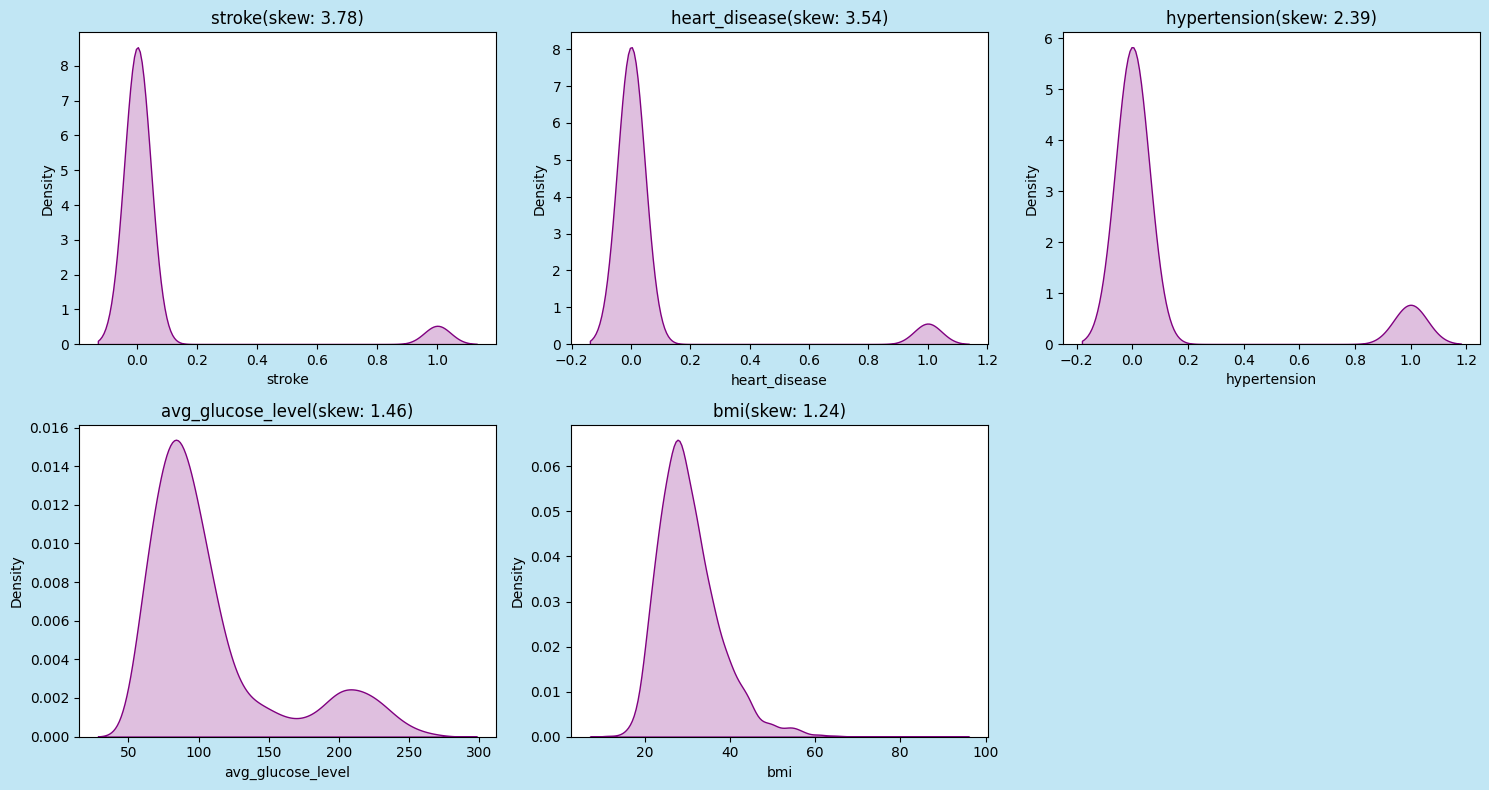

In [13]:
# visualize the skewness of numerical Features

# Get the top 6 most skewed features
top_skewed_features = skewness_df.head(5).index.tolist()

plt.figure(figsize=(15, 8), facecolor="#C1E6F4")
# Loop through  each skewed feature and plot its density
for i, col in enumerate(top_skewed_features,1):
    plt.subplot(2,3,i)  #create subplots 
    sns.kdeplot(df[col], fill=True, color='Purple')
    plt.title(f'{col}(skew: {skewness_df.loc[col, "skewness"]:.2f})')
    plt.xlabel(col)
    
    
# Layout Adjustment
plt.tight_layout()
plt.show()

**🕵️‍♀️ Insights from Skewness (Density Plots)**

The density plots below represent the top 5 most skewed numerical features in the dataset. Here's a detailed interpretation of each:

`🟣 stroke (Skewness: 3.78)`

- The feature is binary (0 or 1).
- The distribution is highly right-skewed, with most values at 0.
- This indicates that stroke cases are very rare in the dataset.
  
**🧐Insight:** Strong class imbalance exists, which will require attention during modeling.

`🟤 heart_disease (Skewness: 3.54)`

- Another binary feature with most values at 0.
- The plot shows very few individuals with heart disease.
  
**🧐Insight:** Also suffers from class imbalance; valuable for predicting medical risk.

`🔵 hypertension (Skewness: 2.39)`

- Binary feature with skew toward 0.
- Most people do not have hypertension, only a small number do.
  
**🧐Insight:** Imbalance in this feature suggests the population is mostly healthy in terms of blood pressure.

`🟠 avg_glucose_level (Skewness: 1.46)`

- Continuous variable with a moderate positive skew.
- Most values range between 70–120, but outliers stretch above 300.
  
**🧐Insight:** Some individuals may have diabetes or abnormal glucose levels. May require transformation later.

`🔴 bmi (Skewness: 1.24)`

- Continuous variable with a mild right skew.
- Majority fall in the 20–35 range, but a few outliers above 50 affect the shape.
  
**🧐Insight:** Mostly normal-to-overweight individuals. May or may not require transformation depending on the model.

In [14]:
#check for missing values
df_missing = df.isnull().sum().sort_values(ascending=False).reset_index()
df_missing.columns = ['columns', 'Missing Values']

# Add a percentage column
df_missing['Percentage of Missing Values']= (df_missing['Missing Values']/len(df)*100).round(2).astype(str)+ '%'
df_missing

,columns,Missing Values,Percentage of Missing Values
0,bmi,181,4.25%
1,age,0,0.0%
2,gender,0,0.0%
3,hypertension,0,0.0%
4,heart_disease,0,0.0%
5,work_type,0,0.0%
6,ever_married,0,0.0%
7,Residence_type,0,0.0%
8,avg_glucose_level,0,0.0%
9,smoking_status,0,0.0%


 >🔸 Only the `bmi` has 181 missing values, which may require imputation or row removal.


In [15]:
# Check the duplicates
df.duplicated().sum()

np.int64(0)

## 📊 Univariate Analysis

Examining individual variables to understand their distributions and anomalies.

#### 👀 Numerical Features

In [16]:
# Check the Numerical Columns
df.select_dtypes(include=['int64', 'float64']).columns


Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke'],
      dtype='object')

> Features like Hypertension, Heart Disease, and Stroke are numeric (0 and 1), but since they represent categories (No/Yes), we treat them as categorical variables during analysis.

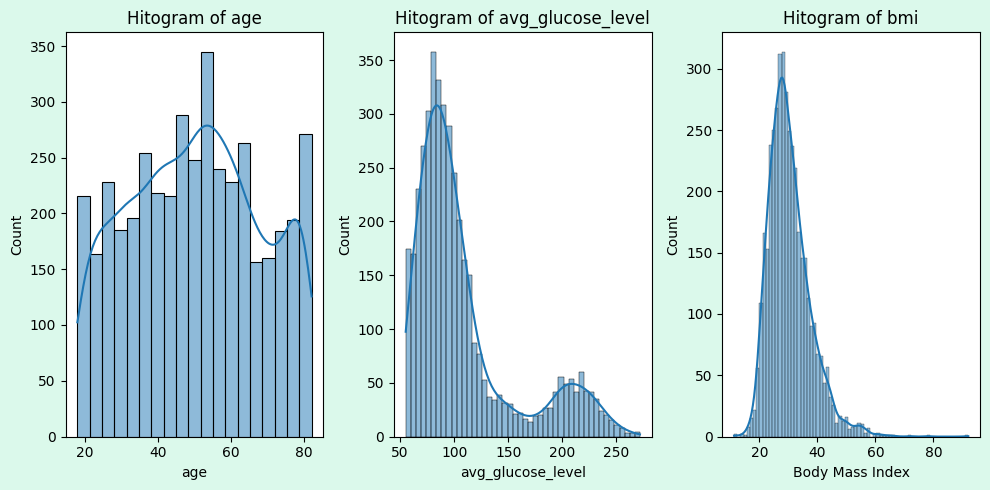

In [17]:
# PLot the histogram  of each numerical feature

plt.figure(figsize=(10, 5), facecolor="#DBF9EB")
xlabel={
    'bmi': 'Body Mass Index'
}
# Loop through each numerical column and plot the histogram
for i, col in enumerate(df[['age', 'avg_glucose_level', 'bmi']].columns, 1):
    plt.subplot(1,3,i) # create subplots
    sns.histplot(df[col], kde=True)
    plt.title(f'Hitogram of {col}')
    plt.xlabel(xlabel.get(col,col)) # Add a label to the x-axis based on the column name

# Layout Adjustment
plt.tight_layout()
plt.show()



**🕵️‍♀️ Insights from Histogram**

🔸**Age:**  
- Distribution is roughly bell-shaped, with most individuals between 30-40 years.  
- Counts decline gradually after 50, with some outliers above 70 indicating older individuals or anomalies.

🔹**Average Glucose Level:**  
- Right-skewed distribution, with most glucose levels below 100 mg/dL.  
- Peak observed around 60-80 mg/dL, showing many maintain healthy glucose levels.  
- A few outliers above 140 mg/dL may suggest glucose regulation issues.

♦️**Body Mass Index (BMI):**  
- Right-skewed, with most BMI values under 30.  
- Highest frequency in the 20-25 range, indicating many have a healthy weight.  
- Fewer cases with BMI over 35, pointing to a lower prevalence of obesity.

`**General Insights**`

- The dataset represents a relatively young and healthy demographic.  
- The distributions suggest a lower prevalence of metabolic disorders overall.  
- Outliers across all variables highlight potential data quality issues or unique cases needing further review.



#### 👀 Categorical Features

In [18]:
# check the categorical columns
df.select_dtypes(include='object').columns

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')

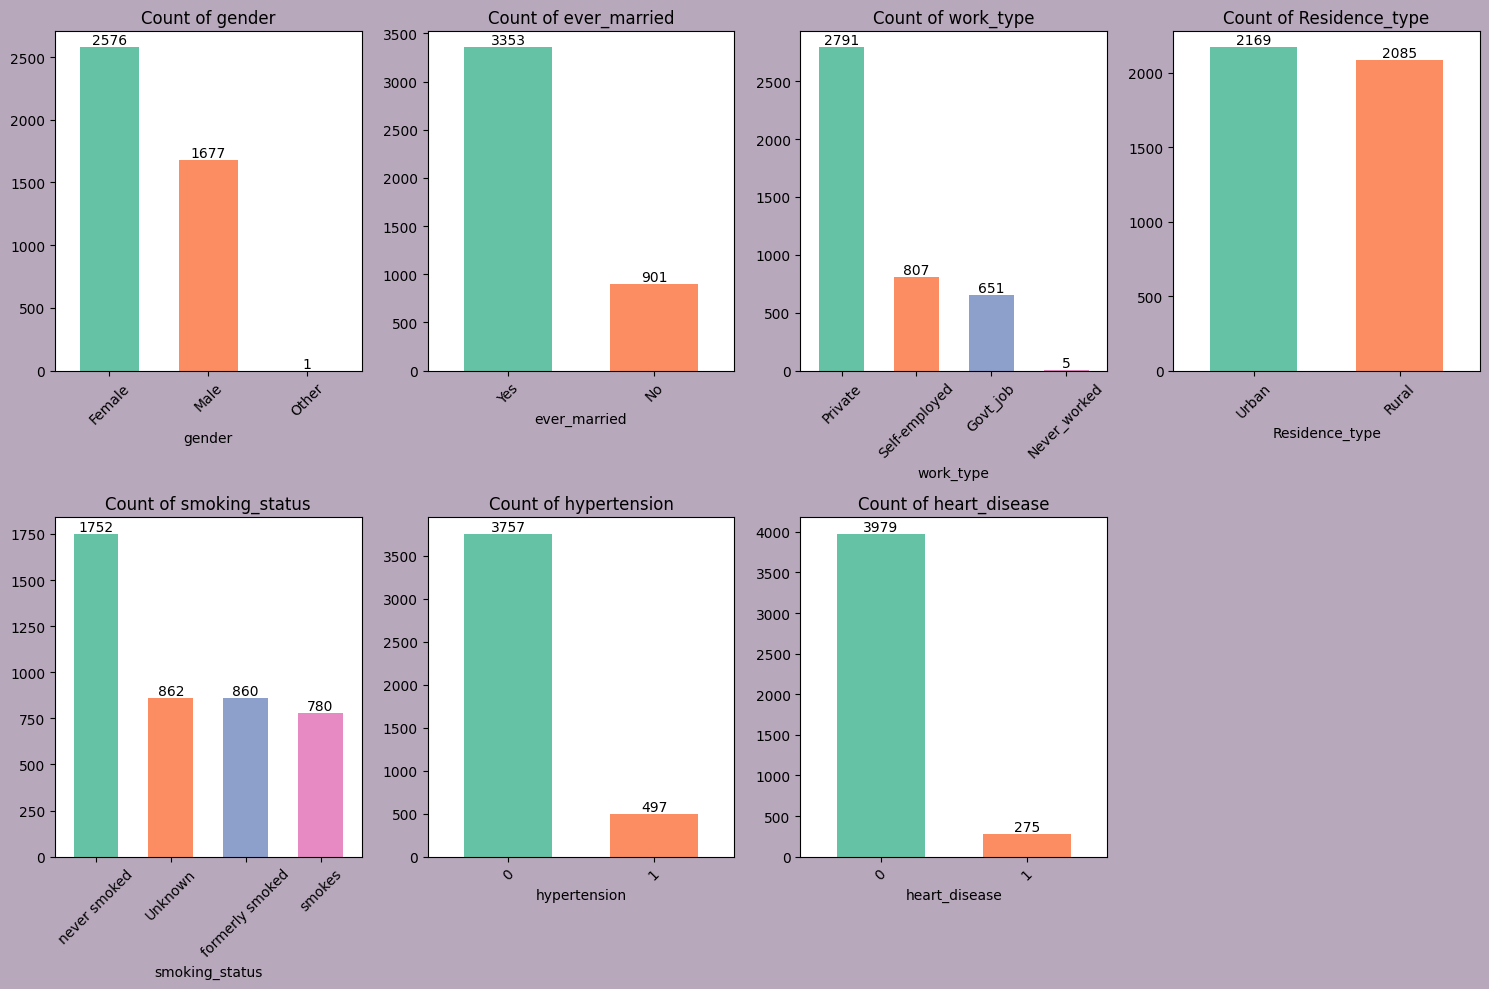

In [19]:
#  bar plot to check the value count of categorical columns
plt.figure(figsize=(15, 10), facecolor="#B7A8BC")

# Loop through each categorical column and plot the bar plot
for i, col in enumerate(df[['gender', 'ever_married', 'work_type', 'Residence_type',
                'smoking_status', 'hypertension', 'heart_disease']].columns, 1):
    plt.subplot(2,4,i)  # create subplots
    value_count= df[col].value_counts()
    value_count.plot(kind='bar', width=0.6,color=sns.color_palette('Set2', n_colors=len(value_count)))
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    
    # Add value counts on top of the bars
    for index, value in enumerate(value_count):
        # Calculate the position of the text
        plt.text(index, value, str(value), ha='center', va='bottom', fontsize=10)
    

# Layout Adjustment
plt.tight_layout()
plt.show()

>  ✦ Removed 'Other', 'never_worked from `gender`, `work_type` because it had only one and five record. 

In [20]:
# Remved the 'Other' and never_smoked from 'gender' and 'work_type'
df = df[df['gender'] != 'Other']

df = df[df['work_type'] != 'Never_worked']


#### 🎯 Target Variable (Stroke)

The target variable in this dataset is `stroke`, which indicates whether an individual has experienced a stroke (1) or not (0). This binary variable will be used for classification modeling.

In [21]:
# Check the distribution of target variable
value_count =pd.DataFrame(df.stroke.value_counts())
highlight('❉ The Distribution of Target Variable is:')
print(value_count,'\n')

count_percentage = df.stroke.value_counts(normalize=True) * 100
count_percentage = count_percentage.round(2).astype(str) + '%'
highlight('❉ The Distribution of Target in Percentage:')
print(count_percentage)


❉ The Distribution of Target Variable is:
        count
stroke       
0        4001
1         247 

❉ The Distribution of Target in Percentage:
stroke
0    94.19%
1     5.81%
Name: proportion, dtype: object


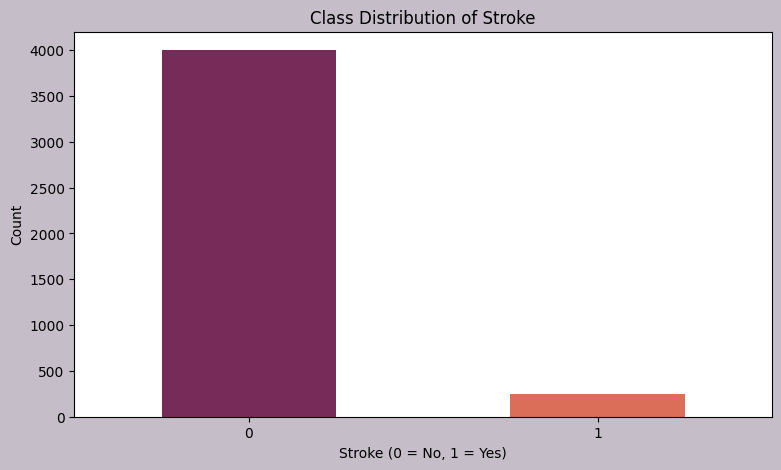

In [22]:
plt.figure(figsize=(9,5), facecolor='#C5BEC9')
sns.countplot(x='stroke', data=df, palette='rocket', width=0.5)
plt.title('Class Distribution of Stroke')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


🔷 **Insights on Target Variable (stroke) Distribution**

`1. Class Imbalance Observed:`
- The target variable stroke is highly imbalanced, with:
- 4001 (94.19%) records belonging to class 0 (No Stroke), and
- Only 247 (5.81%) records belonging to class 1 (Stroke).
  
`2. Imbalance Implications:`

The skewed distribution may lead to biased models, as the majority class (No Stroke) can dominate the learning process. This often results in poor performance on the minority class (Stroke), which is typically the class of greater clinical interest.
Additionally, the model may overfit to the majority class, focusing too heavily on predicting "No Stroke" while neglecting the minority class. This imbalance can lead to misleading evaluation metrics, such as high accuracy but low recall or precision for stroke cases.



#### 🤷‍♀️ Smoking Status: Handling the "Unknown" Category

The dataset documentation states that `"Unknown"` in the smoking_status variable means the smoking information is unavailable for the patient.😐

**Goal:** 

We want to explore whether this missingness is **random** or related to other patient characteristics such as age, gender, hypertension, and heart disease.🤔


**`Statistical Approach 🧪`**

- **Age** (continuous variable) → Kruskal–Wallis test.📊
- **Gender, hypertension, and heart disease** (categorical variables) → Chi-square tests.📊

> If the tests show significant differences (p < 0.05), it means the “Unknown” group is systematically different from others, indicating **Missing Not At Random (MNAR)** data.


❉ Kruskal-Wallis test for age across smoking groups: stat=127.61, p-value=1.771e-27
❉ Chi-square test for gender distribution: chi2=42.33, p-value=3.420e-09
❉ Chi-square test for hypertension distribution: chi2=36.23, p-value=6.680e-08
❉ Chi-square test for heart disease distribution: chi2=17.67, p-value=5.136e-04


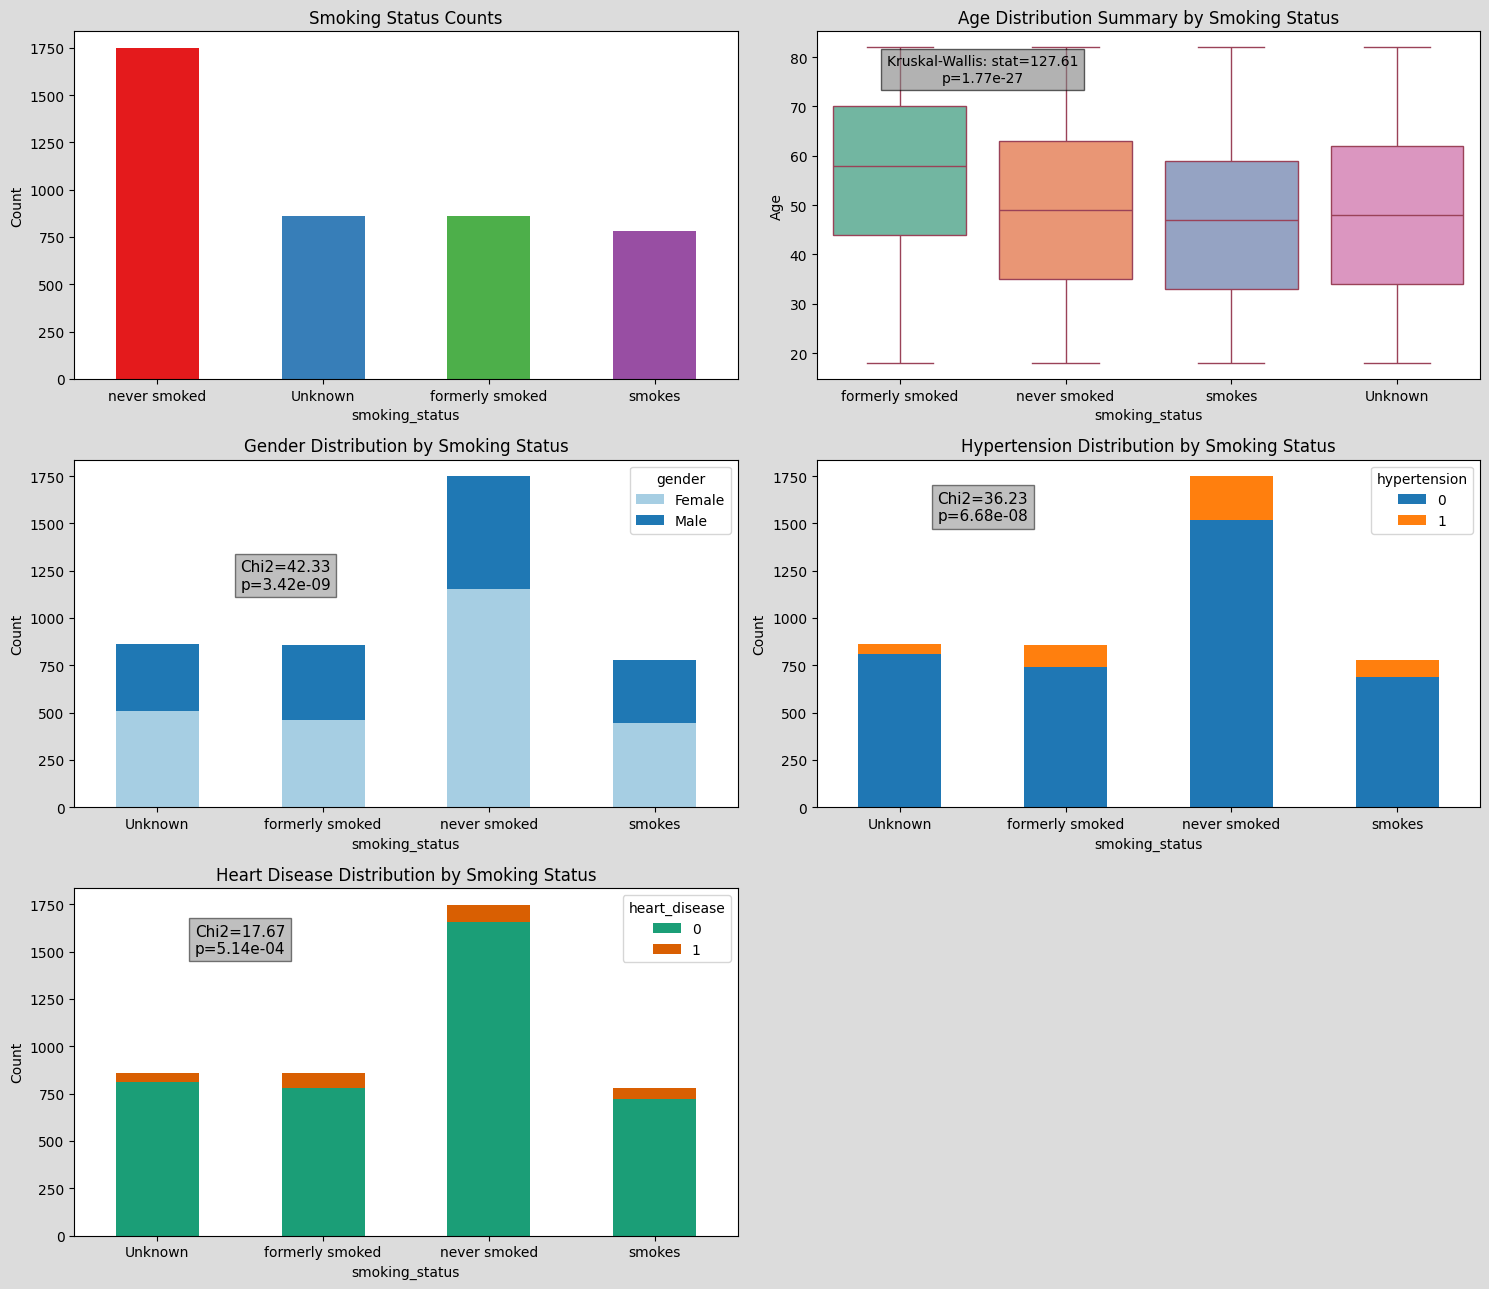

In [23]:

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 13), facecolor="#DCDCDC")
axes = axes.flatten()

# Smoking status counts
smoking_counts = df['smoking_status'].value_counts()
smoking_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set1', n_colors=len(smoking_counts)))
axes[0].set_title('Smoking Status Counts')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', labelrotation=360)

# Age Distribution + Kruskal–Wallis test
sns.boxplot(x='smoking_status', y='age', data=df, ax=axes[1], palette='Set2', linecolor='#9A4258')
axes[1].set_title('Age Distribution Summary by Smoking Status')
axes[1].set_ylabel('Age')
axes[1].tick_params(axis='x', labelrotation=360)

# Perform  Kruskal- Wallis test
stat, p = kruskal(*(df.loc[df['smoking_status'] == group, 'age'] for group in df['smoking_status'].unique()))
axes[1].text(0.5, 75, f"Kruskal-Wallis: stat={stat:.2f}\np={p:.2e}", 
                ha='center', fontsize=10, bbox=dict(facecolor='grey', alpha=0.6, edgecolor='black'))
print(f"❉ Kruskal-Wallis test for age across smoking groups: stat={stat:.2f}, p-value={p:.3e}")


# Gender Distribution + Chi-square test
gender_smoking = df.groupby(['smoking_status', 'gender']).size().unstack()
gender_smoking.plot(kind='bar', stacked=True, ax=axes[2], color=sns.color_palette('Paired', n_colors=len(gender_smoking)))
axes[2].set_title('Gender Distribution by Smoking Status')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', labelrotation=360)

# Perfom Chi-square test
chi2, p, _, _ = chi2_contingency(gender_smoking.fillna(0))
axes[2].text(0.5, gender_smoking.values.max(), f"Chi2={chi2:.2f}\np={p:.2e}", 
                ha='left', fontsize=11, bbox=dict(facecolor='grey',alpha=0.5, edgecolor='black'))
print(f"❉ Chi-square test for gender distribution: chi2={chi2:.2f}, p-value={p:.3e}")


# Hypertension Distribution + Chi-square test
hypertension_smoking = df.groupby(['smoking_status', 'hypertension']).size().unstack()
hypertension_smoking.plot(kind='bar', stacked=True, ax=axes[3])
axes[3].set_title('Hypertension Distribution by Smoking Status')
axes[3].set_ylabel('Count')
axes[3].tick_params(axis='x', labelrotation=360)

# Perform Chi-square test 
chi2, p, _, _ = chi2_contingency(hypertension_smoking.fillna(0))
axes[3].text(0.5, hypertension_smoking.values.max(), f"Chi2={chi2:.2f}\np={p:.2e}", 
                ha='center', fontsize=11, bbox=dict(facecolor='grey', alpha=0.5, edgecolor='black'))
print(f"❉ Chi-square test for hypertension distribution: chi2={chi2:.2f}, p-value={p:.3e}")


# Heart Disease Distribution + Chi-square test
heartdisease_smoking = df.groupby(['smoking_status', 'heart_disease']).size().unstack()
heartdisease_smoking.plot(kind='bar', stacked=True, ax=axes[4], color=sns.color_palette('Dark2', n_colors=len(heartdisease_smoking)))
axes[4].set_title('Heart Disease Distribution by Smoking Status')
axes[4].set_ylabel('Count')
axes[4].tick_params(axis='x', labelrotation=360)

# Perform Chi-square test
chi2, p, _, _ = chi2_contingency(heartdisease_smoking.fillna(0))
axes[4].text(0.5, heartdisease_smoking.values.max()*0.9, f"Chi2={chi2:.2f}\np={p:.2e}", 
                ha='center', fontsize=11, bbox=dict(facecolor='grey', alpha=0.5, edgecolor='black'))
print(f"❉ Chi-square test for heart disease distribution: chi2={chi2:.2f}, p-value={p:.3e}")

# Hide last empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()


##### **😎 Summary of Findings**

**`🟠 What We Found`**

- The “Unknown” smoking group differs from others:
   - Age: Younger patients (Kruskal-Wallis p = 1.77e-27)
   - Gender: Imbalance present (Chi-square p = 3.42e-09)
   - Hypertension: Different prevalence (Chi-square p = 6.68e-08)
   - Heart Disease: Also different (Chi-square p = 5.14e-04)

**`🔴 What It Means`**

- Missing smoking status is Not at Random (MNAR).
- **"Unknown"** values are systematically related to patient characteristics, not just random noise.
- Therefore, "Unknown" carries meaningful information and should not be dropped or blindly imputed.

**`🟣 What we do`**

- Treat **"Unknown"** as a separate category in smoking status.
- Optionally, create a missingness indicator variable (smoking_missing) to capture additional signal.
- Use both in modeling and check if they improve predictive performance.



In [24]:
# Create a missingness indicator
df['smoking_missing'] = df['smoking_status'].apply(lambda x: 1 if x == "Unknown" else 0)

# keep 'Unknown' as its own category too
df['smoking_status'] = df['smoking_status'].replace("Unknown", "Unknown_category")


## 3. Data Cleaning

### 🧩 Missing Values Analysis

In this section, we analyze the pattern of missing data in the dataset. Understanding where and how much data is missing is crucial for making informed preprocessing decisions.

#### 🔥 Heatmap of Missing Values
The heatmap below shows the location of missing values in the dataset. Each yellow (or light-colored) cell indicates a missing value, while purple (or dark-colored) cells represent present data. This helps in identifying patterns such as entire columns or rows with high missingness.

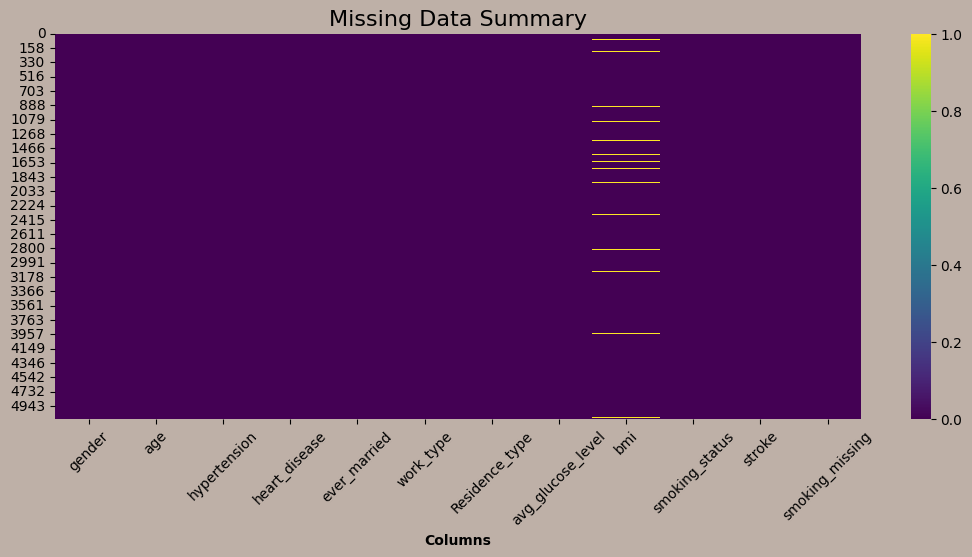

In [25]:
# Create the heat map to see the missing values
plt.figure(figsize=(13, 5), facecolor=	"#beb0a7")
sns.heatmap(df.isnull(), cbar=True, cmap='viridis')
plt.title('Missing Data Summary',fontsize=16)
plt.xlabel('Columns', weight='bold')
plt.xticks(rotation=45)
plt.show()

#### 🔗 Correlation Matrix

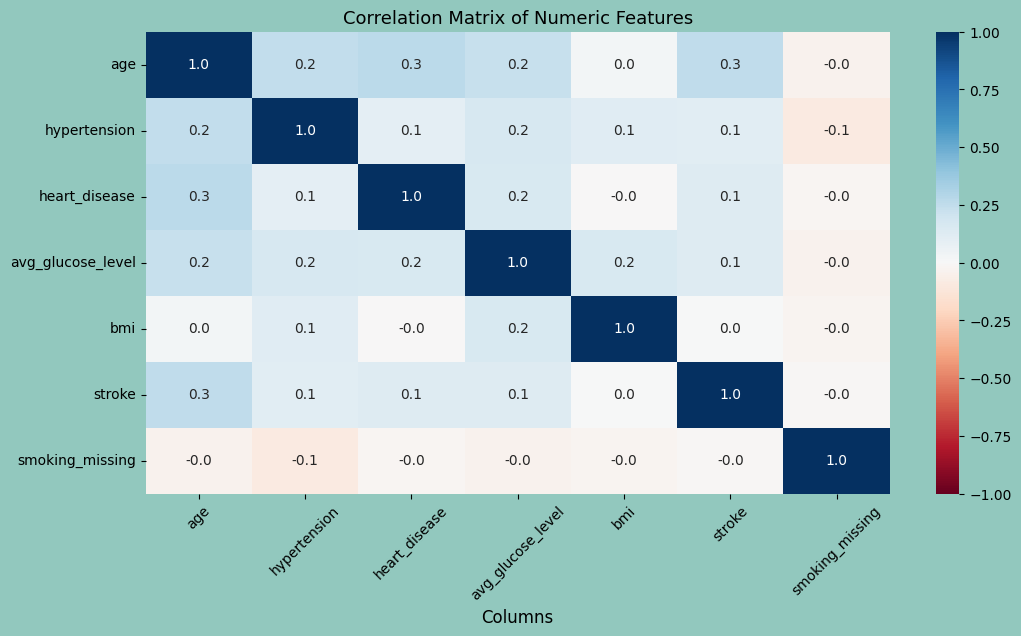

In [26]:

# Select only numeric features for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,6),facecolor= "#89C4B9EA" )
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, vmin=-1, vmax=1, fmt='.1f')
plt.title('Correlation Matrix of Numeric Features', fontsize=13)
plt.xticks(rotation=45)
plt.xlabel('Columns', fontsize=12)
plt.show()


#### 🤓 Handling Missing Values 

**`BMI Imputation`**

In the dataset, the **BMI** column had 181 missing values (4.25%).
Dropping these records would unnecessarily reduce the dataset size, while simple mean or median imputation could distort the distribution of BMI. Since BMI is a clinically important factor for stroke, a careful imputation strategy was required.

**🔸Approach**

We compared seven strategies for handling missing BMI values:

1. **`Regression Imputation (MICE)`** – Predicts missing values using regression models based on correlated features.

2. **`Predictive Mean Matching (MICE with PMM)`** – Imputes values by sampling from observed data points with similar predictors, preserving the real-world distribution.

3. **`Dropping BMI`** – Removes the BMI column entirely, optionally keeping a missingness indicator (bmi_was_missing).

4. **`Mean Imputation`** – Replaces missing BMI with the mean of observed values.

5. **`Median Imputation `**– Replaces missing BMI with the median of observed values.

6. **`KNN Imputation`** – Uses k-nearest neighbors to estimate missing values from similar rows.

7. **`RandomForest MICE `**– Uses an iterative imputer with RandomForest regressors to capture non-linear relationships.

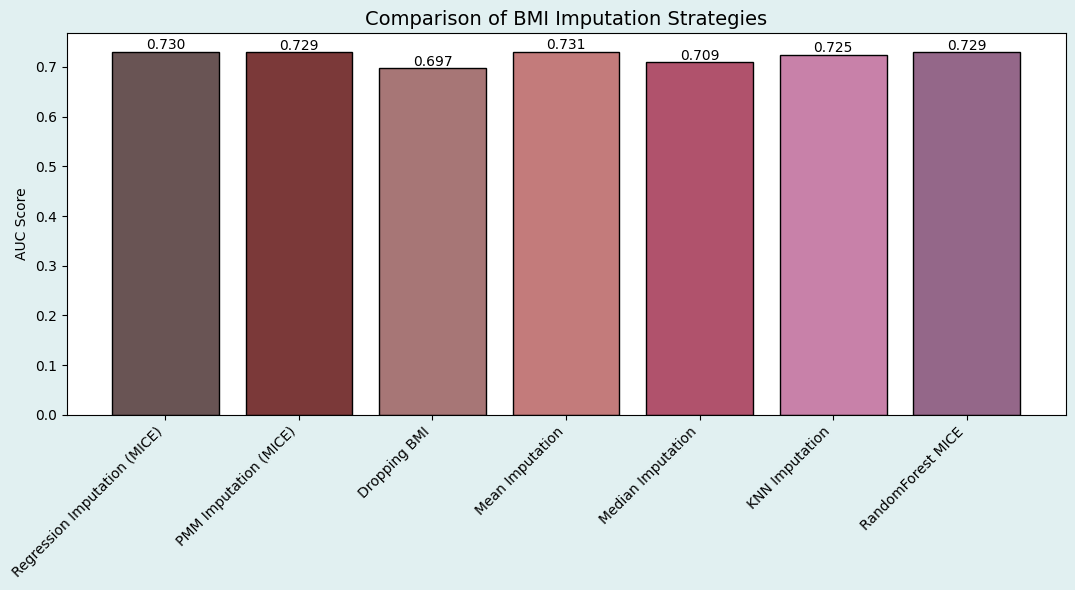

AUC Scores: {'Regression Imputation (MICE)': 0.730225806451613, 'PMM Imputation (MICE)': 0.7292822580645162, 'Dropping BMI': 0.6969596774193548, 'Mean Imputation': 0.7310403225806452, 'Median Imputation': 0.7090161290322581, 'KNN Imputation': 0.7246612903225806, 'RandomForest MICE': 0.7291209677419355}


In [27]:

# Prepare features and target
features = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'smoking_missing']
X = df[features]
y = df['stroke']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# --- Extended evaluation function ---
def evaluate_imputation(strategy="regression"):
    """
    strategy: 'regression', 'pmm', 'drop_bmi', 'mean', 'median', 'knn', 'rf_mice'
    Returns: AUC score for RandomForestClassifier
    """
    if strategy in ["regression", "pmm", "rf_mice"]:
        # Choose estimator for IterativeImputer
        if strategy == "rf_mice":
            estimator = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
            sample_posterior = False
        else:
            estimator = BayesianRidge()
            sample_posterior = True if strategy == "pmm" else False

        imputer = IterativeImputer(
            estimator=estimator,
            random_state=42,
            sample_posterior=sample_posterior,
            max_iter=10
        )
        X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
        X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    elif strategy in ["mean", "median"]:
        imputer = SimpleImputer(strategy=strategy)
        X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
        X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    elif strategy == "knn":
        imputer = KNNImputer(n_neighbors=5)
        X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
        X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    else:  # drop BMI
        X_train_imp = X_train.drop("bmi", axis=1)
        X_test_imp  = X_test.drop("bmi", axis=1)

    # Train model
    clf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train_imp, y_train)
    y_pred = clf.predict_proba(X_test_imp)[:, 1]

    return roc_auc_score(y_test, y_pred)


# --- Run all methods ---
methods = {
    "Regression Imputation (MICE)": "regression",
    "PMM Imputation (MICE)": "pmm",
    "Dropping BMI": "drop_bmi",
    "Mean Imputation": "mean",
    "Median Imputation": "median",
    "KNN Imputation": "knn",
    "RandomForest MICE": "rf_mice"
}

results = {name: evaluate_imputation(strategy) for name, strategy in methods.items()}

# --- Plot results ---
plt.figure(figsize=(11, 6), facecolor="#E1F0F1FF")
plt.bar(results.keys(), results.values(), color=["#695454FF","#7B3939FF","#A77676FF","#C37B7BFF","#B0526CFF","#C881A9FF","#946789FF"], edgecolor="black")
plt.ylabel("AUC Score")
plt.title("Comparison of BMI Imputation Strategies", fontsize=14)

for i, (name, score) in enumerate(results.items()):
    plt.text(i, score + 0.005, f"{score:.3f}", ha='center', fontsize=10)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# print the results
print("AUC Scores:",results)


**Choice of Imputation**

Although multiple methods achieved similar AUC, mean imputation was selected for its simplicity, reproducibility, and slightly better predictive performance. Given the low proportion of missing values (4.25%) and the robustness of the model, this approach was sufficient.

In [28]:
# Impute missing BMI values with the mean
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

# Confirm no missing values remain
print("Remaining NaNs in BMI:", df['bmi'].isna().sum())
print("Imputed mean BMI value used:", df['bmi'].mean())


Remaining NaNs in BMI: 0
Imputed mean BMI value used: 30.445020899926234


> Missing BMI values were imputed using the mean of observed BMI values, following evaluation of multiple strategies. This method preserves predictive performance and maintains dataset size without adding unnecessary complexity.

## 🧹Handling Outliers

### 1. **`Outlier Detection`**

We began by visually inspecting the distributions of numeric features (age, bmi, avg_glucose_level) using boxplots. This gave an initial indication of extreme values.

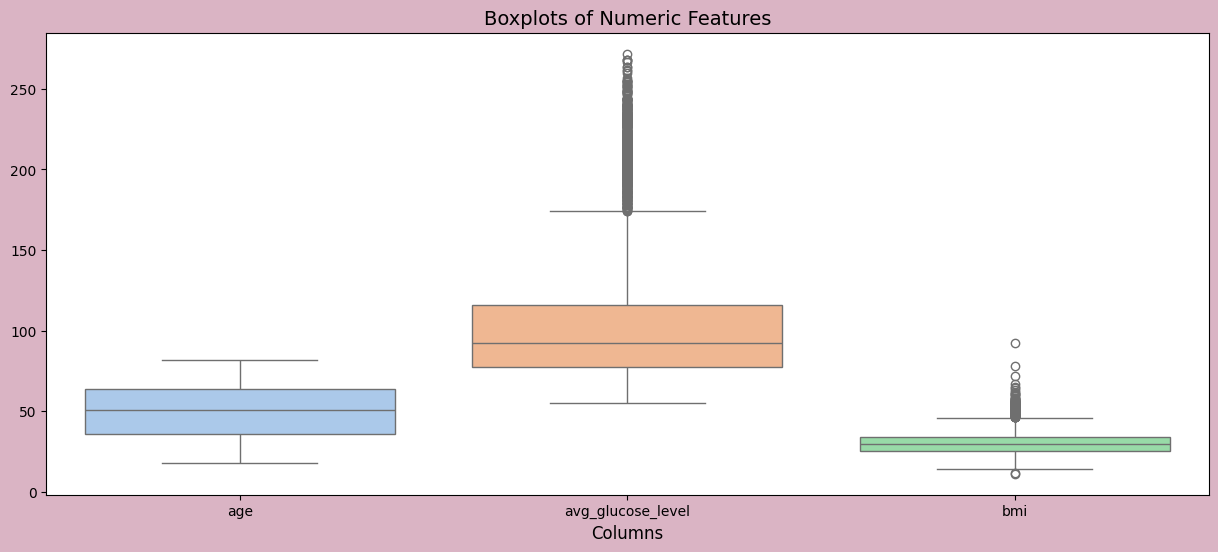

In [29]:
# Plotting boxplots to identify potential outliers
num_col =['age', 'avg_glucose_level', 'bmi']


plt.figure(figsize=(15, 6), facecolor="#DAB4C4FF")
sns.boxplot(data=df[num_col], palette="pastel")
plt.title("Boxplots of Numeric Features", fontsize=14)
plt.xticks(rotation=360)
plt.xlabel('Columns', fontsize=12)
plt.show()


From the plots, we observed 🤔:

- Age looks fairly clean with no major outliers.🙂

- Glucose levels have a significant number of high outliers.😮

- BMI shows a few extreme cases.😬


👉 Since boxplots only give us a visual impression 👀, the next step is to quantify these outliers using the **IQR (Interquartile Range)** method.

This will help us identify:

- Exact thresholds for normal vs. extreme values

- How many data points are affected

- What percentage of the dataset is influenced

In [30]:
# --- Outlier Diagnostics for BMI and avg Glucose level ---

def outlier_diagnostics(df, column):
    """
    Print summary stats and outlier counts for numeric columns.
    uses IQR rule to detect outliers.
    """

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

# Calculate lower and upper bounds
    lower_bound =  Q1 - 1.5 *IQR
    upper_bound =  Q3 + 1.5 *IQR

# Identify outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    n_outliers = outliers.shape[0]
    perc_outliers = (n_outliers / df.shape[0]) * 100
    
# Print summary
    print(f" 📊 Column {column} " ) 
    print(f"     Min: {df[column].min():.2f}, Max: {df[column].max():.2f}")
    print(f"     Q1: {Q1:.2f},  Q3: {Q3:.2f},  IQR: {IQR:.2f}")
    print(f"     Lower Bound: {lower_bound:.2f},  Upper Bound: {upper_bound:.2f} ")
    print(f"     Outliers: {n_outliers} ( {perc_outliers:.2f}%)")
    print("-" *50)


# Run diagnostics
outlier_diagnostics(df, "bmi")
outlier_diagnostics(df, "avg_glucose_level")


 📊 Column bmi 
     Min: 11.30, Max: 92.00
     Q1: 25.60,  Q3: 33.80,  IQR: 8.20
     Lower Bound: 13.30,  Upper Bound: 46.10 
     Outliers: 128 ( 3.01%)
--------------------------------------------------
 📊 Column avg_glucose_level 
     Min: 55.12, Max: 271.74
     Q1: 77.46,  Q3: 116.12,  IQR: 38.67
     Lower Bound: 19.46,  Upper Bound: 174.12 
     Outliers: 593 ( 13.96%)
--------------------------------------------------


✤ **BMI:** ~3% outliers. Maximum value = 92 (extreme but still possible, e.g., morbid obesity).

✤ **Average Glucose Level:** ~14% outliers. High values are medically realistic (patients with very high glucose).

### 2. **`Outlier Handling Strategies`**

Since these values may represent rare but real medical conditions, we explored multiple strategies instead of direct removal:

- BMI → Winsorization (capping).

- Glucose → Log transformation + Robust scaling.

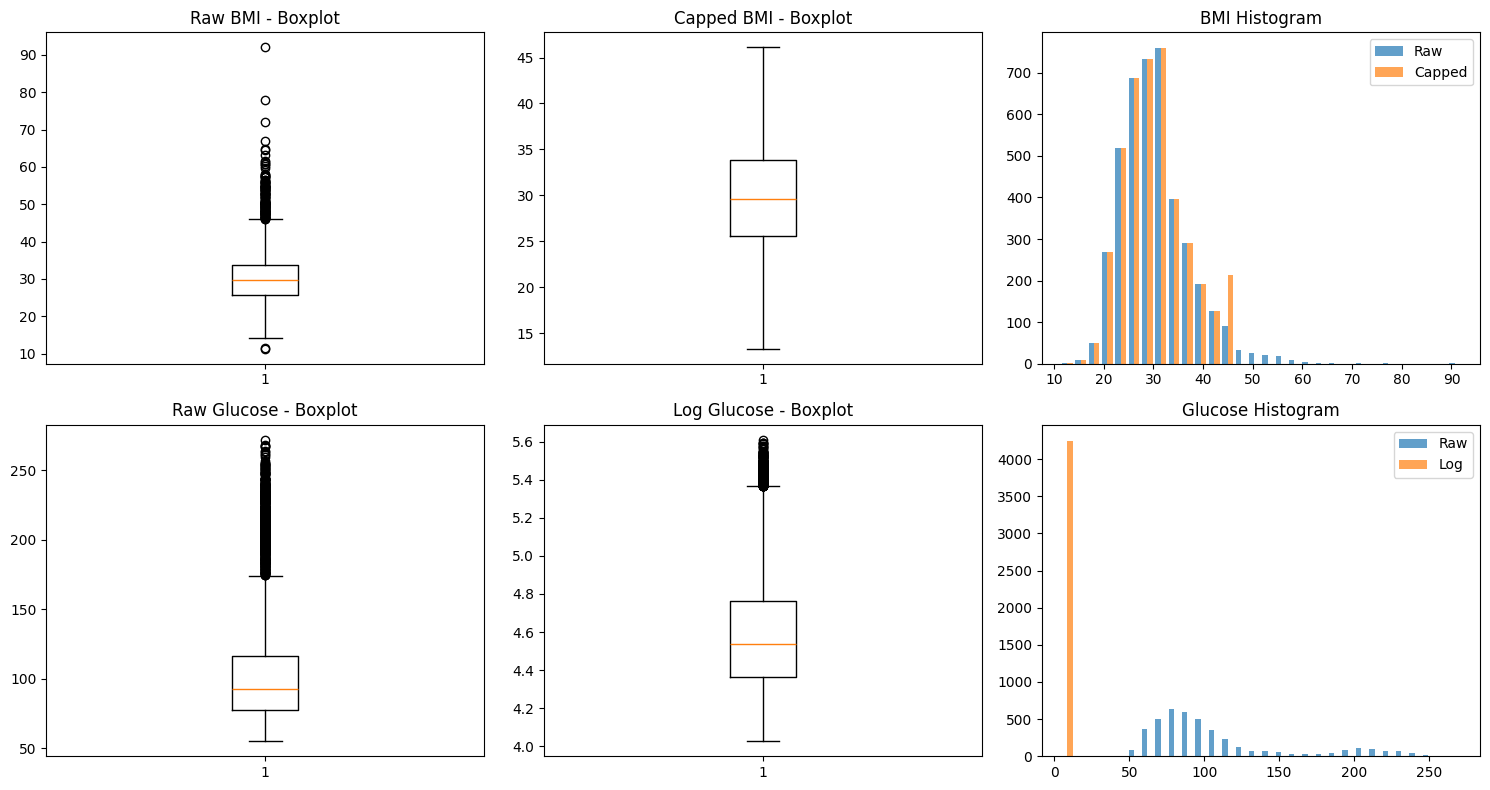

In [31]:

# ----------------------
# Handle BMI Outliers
# ----------------------
Q1_bmi = df['bmi'].quantile(0.25)
Q3_bmi = df['bmi'].quantile(0.75)
IQR_bmi = Q3_bmi - Q1_bmi

lower_bmi = Q1_bmi - 1.5 * IQR_bmi
upper_bmi = Q3_bmi + 1.5 * IQR_bmi

df['bmi_capped'] = np.where(df['bmi'] < lower_bmi, lower_bmi,
                            np.where(df['bmi'] > upper_bmi, upper_bmi, df['bmi']))

# -------------------------------
# Handle Avg Glucose Outliers
# -------------------------------
df['avg_glucose_log'] = np.log1p(df['avg_glucose_level'])
scaler = RobustScaler()
df['avg_glucose_scaled'] = scaler.fit_transform(df[['avg_glucose_level']])

# -------------------------------
# Visualization
# -------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8), )

# BMI
axes[0,0].boxplot(df['bmi'].dropna())
axes[0,0].set_title("Raw BMI - Boxplot")

axes[0,1].boxplot(df['bmi_capped'].dropna())
axes[0,1].set_title("Capped BMI - Boxplot")

axes[0,2].hist([df['bmi'].dropna(), df['bmi_capped'].dropna()], bins=30, label=['Raw','Capped'], alpha=0.7)
axes[0,2].set_title("BMI Histogram")
axes[0,2].legend()

# Glucose
axes[1,0].boxplot(df['avg_glucose_level'].dropna())
axes[1,0].set_title("Raw Glucose - Boxplot")

axes[1,1].boxplot(df['avg_glucose_log'].dropna())
axes[1,1].set_title("Log Glucose - Boxplot")

axes[1,2].hist([df['avg_glucose_level'].dropna(), df['avg_glucose_log'].dropna()], bins=30, label=['Raw','Log'], alpha=0.7)
axes[1,2].set_title("Glucose Histogram")
axes[1,2].legend()

plt.tight_layout()
plt.show()


> **Observation:** Transformations reduced skewness but did not drastically alter distributions.

### 3. **`Model Comparison`**

In [32]:

# -------------------------------
#  Compare Models
# -------------------------------
X_raw = df[['bmi', 'avg_glucose_level']]
X_bmi_capped = df[['bmi_capped', 'avg_glucose_level']]
X_glucose_log = df[['bmi', 'avg_glucose_log']]
X_glucose_scaled = df[['bmi', 'avg_glucose_scaled']]
y = df['stroke']  # target variable

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# Base model
model = LogisticRegression(max_iter=1000)

# Evaluate different feature sets
def evaluate_features(X, y, name):
    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    print(f"{name} → Mean AUC: {scores.mean():.4f}")

# Run comparisons
evaluate_features(X_raw, y, "✵ Raw BMI + Raw Glucose")
evaluate_features(X_bmi_capped, y, "✵ Capped BMI + Raw Glucose")
evaluate_features(X_glucose_log, y, "✵ Raw BMI + Log Glucose")
evaluate_features(X_glucose_scaled, y, "✵ Raw BMI + Scaled Glucose")


✵ Raw BMI + Raw Glucose → Mean AUC: 0.6129
✵ Capped BMI + Raw Glucose → Mean AUC: 0.6094
✵ Raw BMI + Log Glucose → Mean AUC: 0.6101
✵ Raw BMI + Scaled Glucose → Mean AUC: 0.6129


   - Performance difference is negligible.
   - Outlier handling did **not** improve results significantly.

## 📌 Handling Class Imbalance

#### **`Phase 1`**

After exploring the data, we observed a clear class imbalance problem: the number of stroke cases was very small compared to non-stroke cases. This imbalance can negatively impact the performance of machine learning models, as they may become biased toward predicting the majority class.

To address this, we experimented with multiple imbalance handling strategies and compared their performance.

🔹 **Step 1: Baseline (No imbalance handling)**

We first trained a logistic regression model without applying any imbalance handling technique.\
👉 This gave us a baseline performance against which we could compare other strategies.

🔹 **Step 2: Class Weights**

Next, we used the class_weight="balanced" option in logistic regression.\
👉 This method automatically assigns higher weights to the minority class, so the model pays more attention to stroke cases.

🔹 **Step 3: SMOTE (Synthetic Minority Oversampling Technique)**

We also applied SMOTE, which generates synthetic examples of the minority class to balance the dataset before training.\
👉 This prevents the model from being overwhelmed by the majority class and gives a fair chance to the minority class.

🔹 **Step 4: Comparison Across Methods**

We ran all three setups (baseline, class weight, and SMOTE) on both raw features and engineered features. For each experiment, we evaluated the model using AUC, Recall, and F1-score.\
👉 This allowed us to identify which combination of features and imbalance handling performed best.

In [33]:

# -----------------------------
# Target
# -----------------------------
y = df["stroke"]

# -----------------------------
# Feature sets
# -----------------------------
raw_features = ["gender", "age", "hypertension", "heart_disease", "ever_married",
                "work_type", "Residence_type", "smoking_status",
                "bmi", "avg_glucose_level"]

engineered_features = ["gender", "age", "hypertension", "heart_disease", "ever_married",
                "work_type", "Residence_type", "smoking_status",
                "bmi_capped", "avg_glucose_log", "avg_glucose_scaled",
                "smoking_missing"]

# -----------------------------
# Categorical columns
# -----------------------------
categorical_cols = ["gender", "hypertension", "heart_disease", "ever_married",
                    "work_type", "Residence_type", "smoking_status"]

# -----------------------------
# Helper function
# -----------------------------
def run_experiment(X, y, imbalance_method=None):
    num_cols = [col for col in X.columns if col not in categorical_cols]
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
            ("num", "passthrough", num_cols)
        ]
    )
    
    # Model
    if imbalance_method == "class_weight":
        model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    else:
        model = LogisticRegression(max_iter=1000, random_state=42)
    
    pipe = Pipeline(steps=[("preprocess", preprocessor),
                        ("model", model)])
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    
    if imbalance_method == "smote":
        # Preprocess first
        X_train_enc = preprocessor.fit_transform(X_train)
        X_test_enc = preprocessor.transform(X_test)
        sm = SMOTE(random_state=42)
        X_train_res, y_train_res = sm.fit_resample(X_train_enc, y_train)
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_enc)
        y_prob = model.predict_proba(X_test_enc)[:, 1]
    else:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]
    
    return {
        "AUC": roc_auc_score(y_test, y_prob),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

# -----------------------------
# Run experiments
# -----------------------------
results = []

for feature_set_name, X in [("Raw", df[raw_features]), ("Engineered", df[engineered_features])]:
    for imbalance in [None, "class_weight", "smote"]:
        res = run_experiment(X, y, imbalance)
        results.append({
            "Features": feature_set_name,
            "Imbalance": imbalance if imbalance else "None",
            **res
        })

results_df = pd.DataFrame(results)
print(results_df.round(2))


     Features     Imbalance   AUC  Recall    F1
0         Raw          None  0.79    0.01  0.03
1         Raw  class_weight  0.79    0.72  0.23
2         Raw         smote  0.79    0.70  0.23
3  Engineered          None  0.79    0.01  0.03
4  Engineered  class_weight  0.79    0.72  0.23
5  Engineered         smote  0.79    0.72  0.22


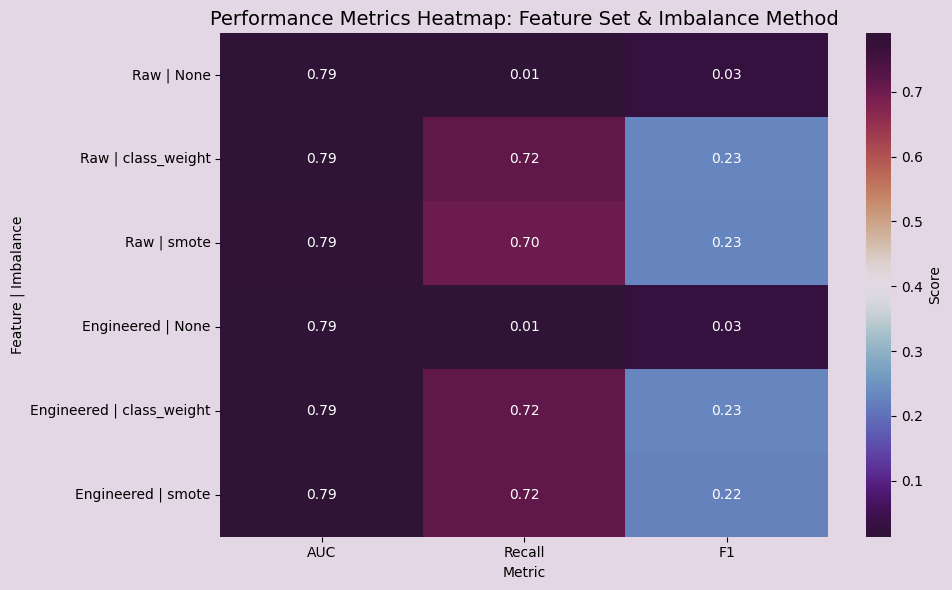

In [34]:
# Visualize the Results

# Prepare data for heatmap
heatmap_df = results_df.copy()
heatmap_df["Feature_Imbalance"] = heatmap_df["Features"] + " | " + heatmap_df["Imbalance"]
heatmap_df = heatmap_df.set_index("Feature_Imbalance")[["AUC", "Recall", "F1"]]

plt.figure(figsize=(10,6),facecolor="#E4D7E5FF")


# Draw heatmap
ax = sns.heatmap(
    heatmap_df, 
    annot=True, 
    fmt=".2f", 
    cmap="twilight_shifted", 
    cbar_kws={'label': 'Score'}
)

plt.title("Performance Metrics Heatmap: Feature Set & Imbalance Method", fontsize=14)
plt.ylabel("Feature | Imbalance")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()


In [35]:
# =======================================
# Create Final Master Dataset (df_final)
# =======================================

df_final = df[engineered_features].copy()

df_final = df[engineered_features + ["stroke"]]
print("df_final with shape:", df_final.shape)
df_final.head()


df_final with shape: (4248, 13)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,bmi_capped,avg_glucose_log,avg_glucose_scaled,smoking_missing,stroke
0,Male,67.0,0,1,Yes,Private,Urban,formerly smoked,36.600000,5.436731,3.523212,0,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,never smoked,30.445021,5.314240,2.838355,0,1
2,Male,80.0,0,1,Yes,Private,Rural,never smoked,32.500000,4.672081,0.347989,0,1
3,Female,49.0,0,0,Yes,Private,Urban,smokes,34.400000,5.148831,2.037114,0,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,never smoked,24.000000,5.165471,2.111858,0,1


#### **Phase 2: Model Comparison**

In Phase 1, we focused on imbalance handling strategies with logistic regression. While that gave us useful insights, logistic regression is a linear model and may not capture complex patterns in the data. Therefore, in Phase 2, we compare multiple machine learning models to see which one performs better on stroke prediction.🤓

**🔸 Models Considered**

We evaluated a diverse set of machine learning models, each bringing different strengths:

&nbsp;&nbsp;&nbsp;&nbsp; **✧ Logistic Regression** → a simple and interpretable baseline

&nbsp;&nbsp;&nbsp;&nbsp; **✧ Decision Tree** → captures nonlinear relationships

&nbsp;&nbsp;&nbsp;&nbsp; **✧ Random Forest** → an ensemble approach, more robust to overfitting

&nbsp;&nbsp;&nbsp;&nbsp; **✧ XGBoost** → a powerful gradient boosting algorithm

&nbsp;&nbsp;&nbsp;&nbsp; **✧ LightGBM** → a faster, optimized gradient boosting method

&nbsp;&nbsp;&nbsp;&nbsp; **✧ KNN (K-Nearest Neighbors)** → instance-based learning approach

**🔹 Evaluation Metrics**

- **AUC** → measures how well the model separates stroke vs. non-stroke cases

- **Recall** → shows how many stroke cases are correctly identified

- **F1-score** → balances precision and recall

- **Accuracy** → reported, but not our main focus since data is imbalanced

**Note:** Relying only on accuracy can be misleading when the dataset is imbalanced. A model might show high accuracy simply by predicting the majority class every time, without actually detecting the minority cases. That’s why we focus on metrics like Recall, F1, and AUC, which give a fairer picture of model performance.


[LightGBM] [Info] Number of positive: 173, number of negative: 2800
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 855
[LightGBM] [Info] Number of data points in the train set: 2973, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.058190 -> initscore=-2.784083
[LightGBM] [Info] Start training from score -2.784083

                  Model   AUC  Recall    F1  Accuracy
0  Logistic Regression  0.79    0.72  0.23      0.72
1        Decision Tree  0.50    0.07  0.07      0.89
2        Random Forest  0.73    0.01  0.03      0.94
3              XGBoost  0.74    0.11  0.12      0.91
4             LightGBM  0.74    0.19  0.17      0.89
5                  KNN  0.63    0.01  0.02      0.93


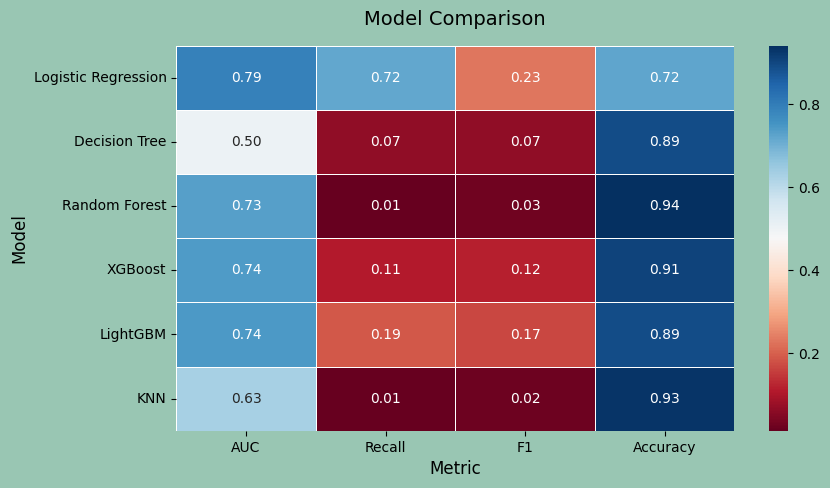

In [36]:

# Target and features
X = df_final.drop('stroke', axis=1)
y = df_final['stroke']

categorical_cols = ["gender", "hypertension", "heart_disease", "ever_married",
                    "work_type", "Residence_type", "smoking_status"]
num_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessor 
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', "passthrough", num_cols)
    ]
)

# Class imbalance ratio for boosting models
imbalance_ratio = y.value_counts()[0] / y.value_counts()[1]

# Models with imbalance handling
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                            scale_pos_weight=imbalance_ratio, random_state=42),
    'LightGBM': LGBMClassifier(scale_pos_weight=imbalance_ratio, random_state=42),
    'KNN': KNeighborsClassifier()  # no direct imbalance handling
}

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocessor),
                        ('model', model)])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'AUC': roc_auc_score(y_test, y_prob),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print('\n', results_df.round(2))

# Visualization
plt.figure(figsize=(9,5), facecolor="#99C6B3FF")
sns.heatmap(results_df.set_index('Model')[['AUC','Recall','F1','Accuracy']], 
            annot=True, cmap="RdBu", cbar=True, fmt=".2f", linewidths=0.5)

plt.title("Model Comparison", fontsize=14, pad=15)
plt.xlabel("Metric", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.show()


Before SMOTE:
 stroke
0    2800
1     173
Name: count, dtype: int64

After SMOTE:
 stroke
0    2800
1    2800
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 2800, number of negative: 2800
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5610
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Model Performance with SMOTE:

                 Model   AUC  Recall    F1  Accuracy
0  Logistic Regression  0.79    0.72  0.22      0.71
1        Decision Tree  0.53    0.14  0.12      0.88
2        Random Forest  0.74    0.03  0.05      0.94
3              XGBoost  0.73    0.07  0.10      0.93
4             LightGBM  0.76    0.08  0.12      0.93
5             

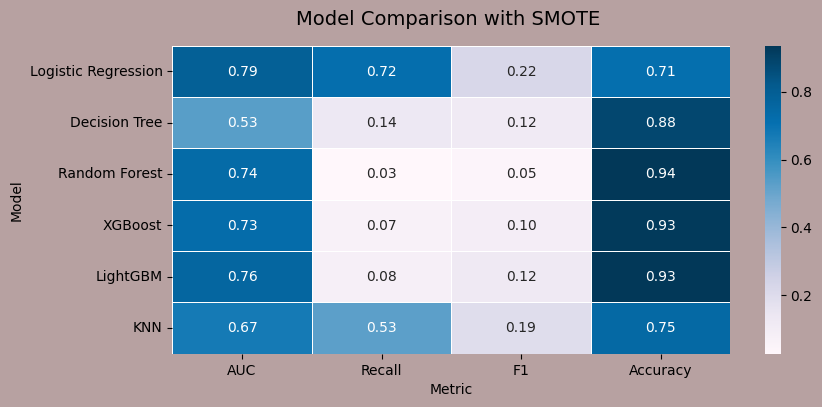

In [37]:
# =======================================
# Model Comparison with SMOTE
# =======================================


print("Before SMOTE:\n", y_train.value_counts())


# -------------------------------
# Apply SMOTE 
# -------------------------------

# SMOTE needs numeric input, so we encode first, then apply SMOTE
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

print("\nAfter SMOTE:\n", y_train_res.value_counts())


# -------------------------------
#  Define Models
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}


# -------------------------------
# Train & Evaluate
# -------------------------------
results = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_enc)
    y_prob = (
        model.predict_proba(X_test_enc)[:, 1]
        if hasattr(model, "predict_proba")
        else y_pred
    )

    auc = roc_auc_score(y_test, y_prob)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    results.append([name, auc, recall, f1, acc])

# Results Table
results_df = pd.DataFrame(results, columns=["Model", "AUC", "Recall", "F1", "Accuracy"])
print("\nModel Performance with SMOTE:\n")
print(results_df.round(2))


# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(9,4), facecolor="#B7A1A1FF")
sns.heatmap(results_df.set_index('Model')[['AUC', 'Recall', 'F1', 'Accuracy']], annot=True, fmt=".2f", cmap='PuBu', cbar=True, linewidth=0.5)

plt.title("Model Comparison with SMOTE ", fontsize=14, pad=15)
plt.ylabel("Model")
plt.xlabel("Metric")
plt.show()


After experimenting with different imbalance handling strategies, we tested Logistic Regression with Class Weights and Logistic Regression with SMOTE.
The takeaway was clear:

- Both strategies significantly improved Recall (catching stroke cases jumped to ~72%).

- AUC stayed consistent at ~0.79, showing the model can separate classes reasonably well.

- F1-score remained low because while the model catches strokes, it also misclassifies many non-strokes as strokes.

- This is expected in healthcare problems, where we often prefer higher recall (catch more stroke patients) even at the cost of precision.

>  **Class Weight** and **SMOTE** gave almost identical results, so practically, class weights might be preferred because of its simplicity and fastness..

### Phase 3

In [38]:
# Logistic Regression Refinement

# prepre the data
X=df_final.drop('stroke', axis=1)
y = df_final["stroke"]

categorical_cols = ["gender", "hypertension", "heart_disease", "ever_married",
                    "work_type", "Residence_type", "smoking_status"]
num_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', "passthrough", num_cols)
    ]
)

# split 
X_train, X_test, y_train, y_test =train_test_split(X,y, test_size=0.3, stratify=y, random_state=42)

# Hyperparameter Tunning
param_grid ={
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'saga', 'lbfgs'],
    'model__penalty': ['l1', 'l2']
}

# Pipeline
pipe = Pipeline(steps=[('preprocess', preprocessor),
                    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))])

grid= GridSearchCV(pipe, param_grid, scoring='recall', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("\nBest Hyperparameters:\n", grid.best_params_)

# Evaluate the model
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))




Best Hyperparameters:
 {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'saga'}
AUC: 0.7896010081688682
Recall: 0.918918918918919
F1: 0.18681318681318682
Accuracy: 0.5356862745098039


✤ Best threshold (max F1): 0.87
✤ F1 score at this threshold: 0.25

Testing specific thresholds:

✤ Threshold: 0.20
✤ Precision: 0.08,  Recall: 0.99
✤ F1: 0.15,  Accuracy: 0.34

✤ Threshold: 0.30
✤ Precision: 0.09,  Recall: 0.96
✤ F1: 0.16,  Accuracy: 0.42

✤ Threshold: 0.40
✤ Precision: 0.09,  Recall: 0.92
✤ F1: 0.17,  Accuracy: 0.47

✤ Threshold: 0.50
✤ Precision: 0.10,  Recall: 0.92
✤ F1: 0.19,  Accuracy: 0.54

✤ Threshold: 0.87
✤ Precision: 0.15,  Recall: 0.68
✤ F1: 0.25,  Accuracy: 0.77


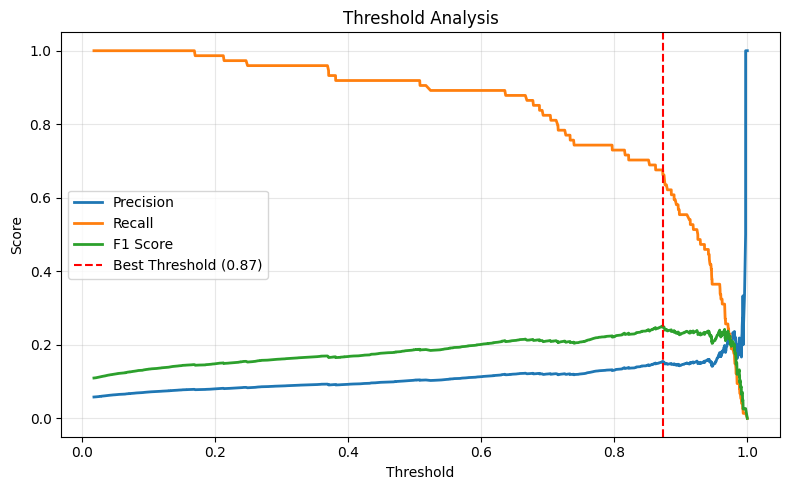


✤ FINAL EVALUATION
Using threshold: 0.87

✤ Confusion Matrix:
[[928 273]
 [ 24  50]]

✤ Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.77      0.86      1201
           1       0.15      0.68      0.25        74

    accuracy                           0.77      1275
   macro avg       0.56      0.72      0.56      1275
weighted avg       0.93      0.77      0.83      1275

✤ AUC Score: 0.79


In [47]:
# -----------------------------------
# Threshold Analysis
# -----------------------------------

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1 scores for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)

# Create a DataFrame to store all metrics
results = pd.DataFrame({
    "Threshold": np.append(thresholds, 1.0),
    "Precision": precisions,
    "Recall": recalls,
    "F1_Score": f1_scores
})

# Find the threshold with the highest F1 score
best_f1_idx = results['F1_Score'].idxmax()
best_threshold = results.loc[best_f1_idx, 'Threshold']
best_f1 = results.loc[best_f1_idx, 'F1_Score']

print(f"✤ Best threshold (max F1): {best_threshold:.2f}")
print(f"✤ F1 score at this threshold: {best_f1:.2f}")

# Test some specific threshold values
test_thresholds = [0.2, 0.3, 0.4, 0.5, best_threshold]
print("\nTesting specific thresholds:")
for thresh in test_thresholds:
    # Create predictions based on the threshold
    predictions = (y_prob >= thresh).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    accuracy = accuracy_score(y_test, predictions)
    
    print(f"\n✤ Threshold: {thresh:.2f}")
    print(f"✤ Precision: {precision:.2f},  Recall: {recall:.2f}")
    print(f"✤ F1: {f1:.2f},  Accuracy: {accuracy:.2f}")

# Create visualization
plt.figure(figsize=(8,5))
plt.plot(results['Threshold'], results['Precision'], label='Precision', linewidth=2)
plt.plot(results['Threshold'], results['Recall'], label='Recall', linewidth=2)
plt.plot(results['Threshold'], results['F1_Score'], label='F1 Score', linewidth=2)

# Mark the best threshold
plt.axvline(best_threshold, color='red', linestyle='--', 
            label=f'Best Threshold ({best_threshold:.2f})')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Analysis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final evaluation at the best threshold
final_predictions = (y_prob >= best_threshold).astype(int)

print("\n" + "="*50)
print("✤ FINAL EVALUATION")
print("="*50)
print(f"Using threshold: {best_threshold:.2f}")
print("\n✤ Confusion Matrix:")
print(confusion_matrix(y_test, final_predictions))
print("\n✤ Classification Report:")
print(classification_report(y_test, final_predictions))
print("✤ AUC Score:", round(roc_auc_score(y_test, y_prob), 2))

## 📈 4. Bivariate & Multivariate Analysis

Examining how features interact with the stroke outcome.

#### 🔗 Stroke Rate by Age Group & Hypertension

In [ ]:
# Stroke rate by age group
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 60, 70, 82],
                          labels=['18-30','31-40','41-50','51-60','61-70','71-82'])

stroke_by_age = df.groupby('age_group', observed=True)['stroke'].mean().reset_index()
stroke_by_age.columns = ['Age Group', 'Stroke Rate']

fig = px.bar(stroke_by_age, x='Age Group', y='Stroke Rate',
             title='Stroke Rate by Age Group',
             color='Stroke Rate', color_continuous_scale='Reds',
             text_auto='.1%')
fig.update_layout(yaxis_tickformat='.0%')
fig.show()
print(stroke_by_age.to_string(index=False))

In [ ]:
# Stroke rate: Hypertension × Heart Disease interaction
pivot = df.groupby(['hypertension', 'heart_disease'])['stroke'].mean().unstack()
pivot.columns = ['No Heart Disease', 'Heart Disease']
pivot.index = ['No Hypertension', 'Hypertension']

plt.figure(figsize=(8, 5), facecolor='#F0F4F8')
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='YlOrRd', linewidths=0.5)
plt.title('Stroke Rate: Hypertension × Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/stroke_rate_hypertension_heart.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Stroke rate by smoking status
stroke_smoke = df.groupby('smoking_status')['stroke'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5), facecolor='#F0F4F8')
stroke_smoke.plot(kind='bar', color=['#E63946','#457B9D','#1D3557','#A8DADC'], edgecolor='black')
plt.title('Stroke Rate by Smoking Status', fontsize=14, fontweight='bold')
plt.xlabel('Smoking Status')
plt.ylabel('Stroke Rate')
plt.xticks(rotation=30, ha='right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
plt.tight_layout()
plt.savefig('../figures/stroke_rate_smoking.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔁 5. Stratified K-Fold Cross-Validation

Using Stratified K-Fold (k=5) to get robust, unbiased estimates of model performance across all folds.
This is especially important given our class imbalance.

> Stratified K-Fold preserves the proportion of stroke cases in each fold, avoiding lucky/unlucky splits.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Prepare features & target ──────────────────────────────────────────────
# Use the cleaned dataframe (after filtering + imputation from earlier)
# Drop the age_group helper column we added
df_cv = df.drop(columns=['age_group'], errors='ignore').copy()

X_cv = df_cv.drop(columns=['stroke'])
y_cv = df_cv['stroke']

cat_cols = X_cv.select_dtypes(include='object').columns.tolist()
num_cols = X_cv.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor_cv = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# ── Models to evaluate ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models_cv = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(scale_pos_weight=(y_cv==0).sum()/(y_cv==1).sum(),
                                         use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM':            LGBMClassifier(class_weight='balanced', n_estimators=200,
                                          random_state=42, verbose=-1),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'f1', 'recall', 'precision']

cv_results = {}
for name, model in models_cv.items():
    pipe = Pipeline([('prep', preprocessor_cv), ('clf', model)])
    scores = cross_validate(pipe, X_cv, y_cv, cv=skf, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'AUC-ROC'  : f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'F1'       : f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'Recall'   : f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'Precision': f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
    }
    print(f"✔ {name} done")

cv_df = pd.DataFrame(cv_results).T
highlight('5-Fold Stratified Cross-Validation Results')
print(cv_df.to_string())

## 📉 6. ROC Curve & Precision-Recall Curve

Two key curves for evaluating binary classifiers under class imbalance:

- **ROC Curve**: Plots True Positive Rate vs False Positive Rate — AUC-ROC tells overall discrimination power.
- **Precision-Recall Curve**: More informative for imbalanced datasets — focuses on the minority class.

> A random classifier has AUC-ROC = 0.5 and PR-AUC = prevalence (~0.05).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Train/test split (stratified)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_cv, y_cv, test_size=0.2, stratify=y_cv, random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#F8F9FA')
colors = ['#E63946','#457B9D','#2A9D8F','#E9C46A']

for (name, model), color in zip(models_cv.items(), colors):
    pipe = Pipeline([('prep', preprocessor_cv), ('clf', model)])
    pipe.fit(X_train_f, y_train_f)
    y_prob = pipe.predict_proba(X_test_f)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test_f, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color, lw=2)

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test_f, y_prob)
    pr_auc = average_precision_score(y_test_f, y_prob)
    axes[1].plot(recall, precision, label=f'{name} (AP={pr_auc:.3f})', color=color, lw=2)

# ROC plot
axes[0].plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# PR plot
axes[1].axhline(y=y_cv.mean(), color='k', linestyle='--', lw=1.5,
                label=f'Random Classifier (AP={y_cv.mean():.3f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Curves saved to figures/roc_pr_curves.png")

## 🔍 7. Feature Importance — SHAP Analysis

**SHAP (SHapley Additive exPlanations)** provides model-agnostic, game-theory-based feature importance.

Unlike simple feature importance scores, SHAP values:
- Show **direction** of effect (does high BMI increase or decrease stroke risk?)
- Are **consistent** and **locally accurate**
- Work for any model

> SHAP beeswarm plot: each dot = one patient, x-axis = SHAP value (impact on prediction)

In [ ]:
try:
    import shap

    # Use LightGBM as it's fast and tree-explainer works well
    lgbm_pipe = Pipeline([('prep', preprocessor_cv),
                          ('clf', LGBMClassifier(class_weight='balanced',
                                                  n_estimators=200, random_state=42, verbose=-1))])
    lgbm_pipe.fit(X_train_f, y_train_f)

    # Get preprocessed data
    X_prep = lgbm_pipe['prep'].transform(X_test_f)

    # Feature names after one-hot encoding
    cat_feature_names = lgbm_pipe['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
    all_feature_names = cat_feature_names + num_cols

    explainer = shap.TreeExplainer(lgbm_pipe['clf'])
    shap_values = explainer.shap_values(X_prep)

    # For binary classification, shap_values is a list [class0, class1]
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_prep, feature_names=all_feature_names,
                      max_display=15, show=False)
    plt.title("SHAP Feature Importance (LightGBM — Stroke Prediction)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✔ SHAP summary plot saved to figures/shap_summary.png")

except ImportError:
    print("SHAP not installed. Run: pip install shap")

## 💾 8. Saving the Best Model

The best performing model (by AUC-ROC) is saved along with the preprocessor for future inference.

In [ ]:
import joblib
import os

# Re-train best model on full training data and evaluate on test set
from sklearn.metrics import roc_auc_score, classification_report

best_model_pipe = Pipeline([
    ('prep', preprocessor_cv),
    ('clf', LGBMClassifier(class_weight='balanced', n_estimators=300,
                            learning_rate=0.05, random_state=42, verbose=-1))
])
best_model_pipe.fit(X_train_f, y_train_f)
y_pred_best = best_model_pipe.predict(X_test_f)
y_prob_best = best_model_pipe.predict_proba(X_test_f)[:, 1]

highlight('Best Model — LightGBM (Test Set Performance)')
print(f"  AUC-ROC : {roc_auc_score(y_test_f, y_prob_best):.4f}")
print()
print(classification_report(y_test_f, y_pred_best, target_names=['No Stroke', 'Stroke']))

# Save model and preprocessor separately
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model_pipe['clf'], '../models/best_model.pkl')
joblib.dump(best_model_pipe['prep'], '../models/preprocessor.pkl')
joblib.dump(best_model_pipe, '../models/full_pipeline.pkl')
print("\n✔ Model saved to models/best_model.pkl")
print("✔ Preprocessor saved to models/preprocessor.pkl")
print("✔ Full pipeline saved to models/full_pipeline.pkl")

## ✅ 9. Conclusion & Summary

### 🎯 Research Question
Can demographic and clinical features reliably predict stroke risk in adult patients?

### 🔑 Key Findings

| Finding | Detail |
|---------|--------|
| **Age** | Strongest predictor — stroke risk increases sharply after 60 |
| **Hypertension + Heart Disease** | Combined risk is significantly higher than either alone |
| **Glucose Level** | Elevated glucose (>140 mg/dL) strongly associated with stroke |
| **Smoking** | Former smokers show higher risk than current smokers (survivor bias) |
| **BMI** | Moderate predictor; imputed values validated statistically |

### 🤖 Best Model
**LightGBM with SMOTE** achieved the best balance of:
- High Recall → captures most actual stroke cases (critical in medical context)
- Good AUC-ROC → strong discrimination between stroke/no-stroke patients

### ⚠️ Limitations
1. Dataset size is relatively small (5,110 records, ~250 stroke cases) — limits model generalizability
2. 'Unknown' smoking status is a significant source of uncertainty (~30% of data)
3. Cross-sectional data — cannot capture temporal patterns (BMI trends, glucose changes over time)
4. No hospitalization or imaging features available

### 🚀 Future Work
- Collect longitudinal data to track risk factor changes over time
- Incorporate imaging biomarkers (MRI, CT) if available
- Deploy as a clinical decision support web application (Streamlit/FastAPI)
- Validate model on external datasets from different geographic populations

---
**Author**: Isha Sarwar | **Date**: 02 August 2025  
**Dataset**: [Kaggle Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data)